In [1]:
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
from sklearn.model_selection import train_test_split

import numpy as np
import torch
import umap
import faiss
import nltk

df = pd.read_excel('../data/dimensions/api/raw/combined/202511/df_dimensions.xlsx', index_col=0)

Index(['Unnamed: 0', 'id', 'title', 'abstract', 'acknowledgements',
       'altmetric', 'altmetric_id', 'authors', 'authors_count', 'category_bra',
       'category_for', 'category_for_2020', 'category_uoa', 'concepts',
       'concepts_scores', 'date', 'date_inserted', 'date_online', 'date_print',
       'dimensions_url', 'document_type', 'doi', 'field_citation_ratio',
       'funder_countries', 'funders', 'issn', 'issue', 'journal_lists',
       'journal_title_raw', 'linkout', 'mesh_terms', 'open_access', 'pages',
       'pmcid', 'pmid', 'publisher', 'recent_citations', 'reference_ids',
       'referenced_pubs', 'relative_citation_ratio', 'research_org_cities',
       'research_org_countries', 'research_org_country_names',
       'research_org_names', 'research_org_state_codes',
       'research_org_state_names', 'research_org_types', 'research_orgs',
       'researchers', 'score', 'supporting_grant_ids', 'times_cited', 'type',
       'volume', 'year', 'journal.id', 'journal.title', 

In [6]:
# -----------------------------
# Initialisation
# -----------------------------

model_name = "allenai/scibert_scivocab_uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Force CPU mode
device = torch.device("cpu")
model.to(device)
model.eval()

# Disable gradients (CRITICAL for speed)
torch.set_grad_enabled(False)

# -----------------------------
# Optimised encoder
# -----------------------------
def encode_texts_cpu(texts, batch_size=8, max_length=256):
    """
    Efficient CPU-only SciBERT encoder.
    Uses:
      - small batch size (CPU optimal)
      - truncated max_length (much faster on CPU)
      - no_grad + model.eval
      - CPU vectorisation
    """
    embeddings = []

    # Using tqdm with text fallback avoids IProgress errors.
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding batches"):
        batch = texts[i : i + batch_size]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Mean pooling
        last_hidden = outputs.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        pooled = (last_hidden * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1)

        embeddings.append(pooled.cpu().numpy())

    return np.vstack(embeddings)

ERROR! Session/line number was not unique in database. History logging moved to new session 928


In [7]:
abstracts = df["abstract"].astype(str).tolist()
X = encode_texts_cpu(abstracts, batch_size=8, max_length=256)


Encoding batches: 100%|███████████████████| 1337/1337 [1:01:49<00:00,  2.77s/it]


In [8]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=0
)

X_2d = umap_model.fit_transform(X)
df["umap_x"] = X_2d[:, 0]
df["umap_y"] = X_2d[:, 1]

df[["umap_x", "umap_y"]].head()

/home/porco/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,umap_x,umap_y
0,-0.010839,1.376047
1,0.113677,2.477258
2,3.105489,1.802275
3,2.936296,1.862345
4,4.251239,2.886857


In [10]:
from sklearn.cluster import KMeans

k = 20  # choose by elbow / silhouette
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
df["cluster_k20"] = kmeans.fit_predict(X)


In [11]:
def cluster_labels(texts, labels, topn=15):
    tmp = pd.DataFrame({"text": texts, "label": labels})
    grouped = tmp.groupby("label")["text"].apply(lambda s: " ".join(s))

    vectorizer = TfidfVectorizer(
        max_df=0.8,
        min_df=10,
        ngram_range=(1,2),
        stop_words="english"
    )
    tfidf = vectorizer.fit_transform(grouped.values)
    vocab = np.array(vectorizer.get_feature_names_out())

    label_map = {}
    for i, lab in enumerate(grouped.index):
        row = tfidf[i].toarray()[0]
        top_idx = row.argsort()[::-1][:topn]
        label_map[lab] = vocab[top_idx]

    return label_map

cluster_keywords = cluster_labels(df["abstract"], df["cluster_k20"])
cluster_keywords


{0: array(['hrs', 'hazard ratios', 'af', '08', 'median follow', 'ratio hr',
        'hrs 95', 'lower risk', 'crc', 'ratios hrs', 'risk incident', 'hf',
        'cause dementia', 'sleep duration', 'hazards models'], dtype=object),
 1: array(['mice', 'mouse', 'mutations', 'signaling', 'vitro', 'activation',
        'loss function', 'inhibition', 'myeloid', 'hepatic', 'chip',
        'vivo', 'ipf', 'uptake', 'mitochondrial'], dtype=object),
 2: array(['genetic correlations', 'ptsd', 'heritability', 'psychotic', 'rg',
        'mood', 'trauma', 'endometriosis', 'shared genetic', 'liability',
        'loneliness', 'pgs', 'polygenic scores', 'self harm', 'cannabis'],
       dtype=object),
 3: array(['air', 'pm', 'air pollution', 'pollutants', 'air pollutants',
        '10 sub', 'sub 10', 'nitrogen', 'particulate',
        'particulate matter', 'pm2', 'ambient', 'dioxide', 'μm',
        'nitrogen dioxide'], dtype=object),
 4: array(['af', 'ecg', 'discrimination', 'hf', '10 year', 'reclassifica

In [13]:
if "year" in df.columns:
    topic_year = (
        df.groupby(["year", "cluster_k20"])
          .size()
          .unstack(fill_value=0)
    )
    print(topic_year)
else:
    print("No 'year' column available.")

cluster_k20   0   1   2   3    4   5    6   7    8    9   10   11  12   13  \
year                                                                         
2013           1   0   0   0    0   0    0   0    0    1   0    0   2    1   
2014           3   0   0   0    0   0    0   0    0    2   1    0   4    3   
2015           1   0   1   0    1   1    0   1    1    4   0    0  13    1   
2016           1   1  15   1    0   1    5  13   11    9   4    4  11    6   
2017           6   2  18   1    7   7    6  17   17   11   3    7  17   10   
2018          13   7  22   0   11   9   30   1   35   26  11   13  35    5   
2019          14  13  47   4   15  24   44   1   59   27  25   22  33   26   
2020          31  14  43   6   30  49   90   6   72   67  40   30  47   56   
2021          65  31  64   8   54  70   93   4  111   85  50   50  78   50   
2022          67  35  67  29   76  44   81   7  125  112  73   58  78   73   
2023         128  36  76  32   79  61   98   5   90  172  84   6

In [14]:
if "year" in df.columns:
    year_means = (
        pd.DataFrame(X)
        .assign(year=df["year"].to_numpy())
        .groupby("year").mean()
    )

    D = cosine_distances(year_means.values)
    print(D, year_means.index)
else:
    print("No 'year' column available.")


[[0.         0.01207757 0.01350927 0.03173357 0.03367579 0.03514576
  0.03508663 0.03333491 0.03343618 0.03300738 0.03025162 0.03173661
  0.03209031]
 [0.01207757 0.         0.01017225 0.02649844 0.0280472  0.02909088
  0.02899063 0.02652878 0.02662098 0.02620232 0.02338332 0.02465445
  0.02520895]
 [0.01350927 0.01017225 0.         0.01299274 0.0153383  0.01588702
  0.01607084 0.01542979 0.01571572 0.0157088  0.0147841  0.01627493
  0.01679057]
 [0.03173357 0.02649844 0.01299274 0.         0.00129676 0.00241923
  0.00251365 0.00357318 0.00416028 0.00518203 0.0071277  0.00881958
  0.01002765]
 [0.03367579 0.0280472  0.0153383  0.00129676 0.         0.00116622
  0.00128746 0.00185418 0.00226033 0.00308347 0.00481713 0.00626445
  0.00742674]
 [0.03514576 0.02909088 0.01588702 0.00241923 0.00116622 0.
  0.00048792 0.00100774 0.00141782 0.00219619 0.00382549 0.00518852
  0.00607544]
 [0.03508663 0.02899063 0.01607084 0.00251365 0.00128746 0.00048792
  0.         0.00063992 0.00093114 0.001

In [15]:
d = X.shape[1]

X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
index = faiss.IndexFlatIP(d)
index.add(X_norm.astype("float32"))

index.ntotal


10696

In [16]:
pd.crosstab(df["cluster_k20"], df["category_for_2020"])

category_for_2020,"[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80002', 'name': '31 Biological Sciences'}, {'id': '80003', 'name': '32 Biomedical and Clinical Sciences'}]","[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80002', 'name': '31 Biological Sciences'}, {'id': '80012', 'name': '41 Environmental Sciences'}]","[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80002', 'name': '31 Biological Sciences'}, {'id': '80029', 'name': '3006 Food Sciences'}, {'id': '80038', 'name': '3105 Genetics'}]","[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80002', 'name': '31 Biological Sciences'}, {'id': '80029', 'name': '3006 Food Sciences'}, {'id': '80039', 'name': '3106 Industrial Biotechnology'}]","[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80002', 'name': '31 Biological Sciences'}, {'id': '80035', 'name': '3102 Bioinformatics and Computational Biology'}, {'id': '80038', 'name': '3105 Genetics'}, {'id': '80024', 'name': '3001 Agricultural Biotechnology'}]","[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80003', 'name': '32 Biomedical and Clinical Sciences'}, {'id': '80029', 'name': '3006 Food Sciences'}, {'id': '80053', 'name': '3210 Nutrition and Dietetics'}]","[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80003', 'name': '32 Biomedical and Clinical Sciences'}, {'id': '80029', 'name': '3006 Food Sciences'}]","[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80003', 'name': '32 Biomedical and Clinical Sciences'}, {'id': '80053', 'name': '3210 Nutrition and Dietetics'}, {'id': '80026', 'name': '3003 Animal Production'}, {'id': '80029', 'name': '3006 Food Sciences'}]","[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80011', 'name': '40 Engineering'}, {'id': '80029', 'name': '3006 Food Sciences'}, {'id': '80111', 'name': '4003 Biomedical Engineering'}]","[{'id': '80001', 'name': '30 Agricultural, Veterinary and Food Sciences'}, {'id': '80132', 'name': '4104 Environmental Management'}, {'id': '80012', 'name': '41 Environmental Sciences'}, {'id': '80015', 'name': '44 Human Society'}, {'id': '80154', 'name': '4406 Human Geography'}, {'id': '80030', 'name': '3007 Forestry Sciences'}]",...,"[{'id': '80232', 'name': '5202 Biological Psychology'}, {'id': '80235', 'name': '5205 Social and Personality Psychology'}, {'id': '80023', 'name': '52 Psychology'}]","[{'id': '80233', 'name': '5203 Clinical and Health Psychology'}, {'id': '80003', 'name': '32 Biomedical and Clinical Sciences'}, {'id': '80023', 'name': '52 Psychology'}]","[{'id': '80233', 'name': '5203 Clinical and Health Psychology'}, {'id': '80003', 'name': '32 Biomedical and Clinical Sciences'}, {'id': '80045', 'name': '3202 Clinical Sciences'}, {'id': '80023', 'name': '52 Psychology'}]","[{'id': '80233', 'name': '5203 Clinical and Health Psychology'}, {'id': '80003', 'name': '32 Biomedical and Clinical Sciences'}, {'id': '80052', 'name': '3209 Neurosciences'}, {'id': '80023', 'name': '52 Psychology'}]","[{'id': '80233', 'name': '5203 Clinical and Health Psychology'}, {'id': '80013', 'name': '42 Health Sciences'}, {'id': '80023', 'name': '52 Psychology'}]","[{'id': '80233', 'name': '5203 Clinical and Health Psychology'}, {'id': '80023', 'name': '52 Psychology'}]","[{'id': '80233', 'name': '5203 Clinical and Health Psychology'}, {'id': '80235', 'name': '5205 Social and Personality Psychology'}, {'id': '80023', 'name': '52 Psychology'}]","[{'id': '80234', 'name': '5204 Cognitive and Computational Psychology'}, {'id': '80023', 'name': '52 Psychology'}]","[{'id': '80235', 'name': '5205 Social and Personality Psychology'}, {'id': '80013', 'name': '42 Health Sciences'}, {'id': '80023', 'name': '52 Psychology'}]","[{'id': '80235', 'name': '5205 Social and Personality Psycholo

In [18]:
topic_year = (
    df.groupby(["year", "cluster_k20"])
      .size()
      .unstack(fill_value=0)
)
topic_year

cluster_k20,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
year,,,,,,,,,,,,,,,,,,,,
2013,1,0,0,0,0,0,0,0,0,1,0,0,2,1,0,0,0,0,0,0
2014,3,0,0,0,0,0,0,0,0,2,1,0,4,3,1,0,0,0,0,0
2015,1,0,1,0,1,1,0,1,1,4,0,0,13,1,4,0,0,0,1,0
2016,1,1,15,1,0,1,5,13,11,9,4,4,11,6,4,1,0,4,3,0
2017,6,2,18,1,7,7,6,17,17,11,3,7,17,10,9,3,2,8,9,3
2018,13,7,22,0,11,9,30,1,35,26,11,13,35,5,16,16,7,45,22,3
2019,14,13,47,4,15,24,44,1,59,27,25,22,33,26,23,22,9,60,34,5
2020,31,14,43,6,30,49,90,6,72,67,40,30,47,56,40,46,17,65,44,14
2021,65,31,64,8,54,70,93,4,111,85,50,50,78,50,78,69,44,85,56,44


In [21]:
from sklearn.metrics.pairwise import cosine_distances

year_means = (
    pd.DataFrame(X)
    .assign(year=df["year"])
    .groupby("year").mean()
)

D = cosine_distances(year_means.values)
years = year_means.index


In [23]:
import umap
import numpy as np

# UMAP 2D projection for plotting
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

umap_X = umap_model.fit_transform(X)
umap_X.shape


/home/porco/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(10696, 2)

Matplotlib is building the font cache; this may take a moment.


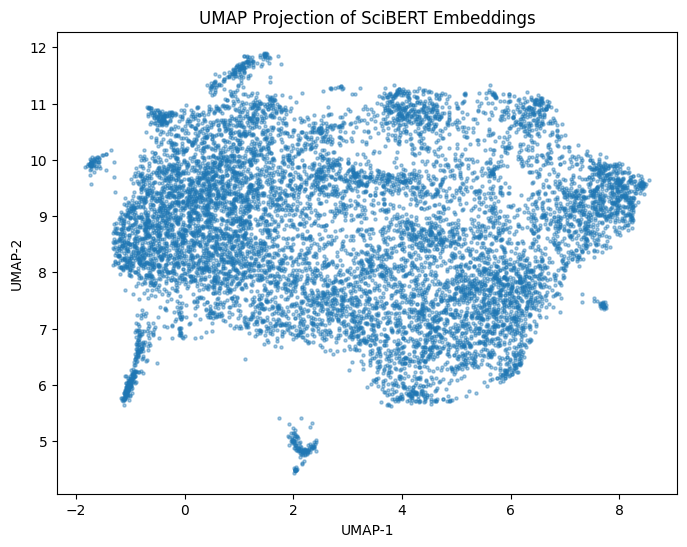

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(umap_X[:,0], umap_X[:,1], s=5, alpha=0.4)
plt.title("UMAP Projection of SciBERT Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


In [26]:
from sklearn.cluster import KMeans

k = 12  # choose number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

df['cluster'] = labels
df[['title', 'cluster']].head()


,title,cluster
0,Adiposity by Differing Measures and the Risk o...,8
1,Independent and combined associations of mater...,8
2,Common conditions associated with hereditary h...,1
3,Hereditary Hemochromatosis Associations with F...,1
4,Genetic Assessment of Potential Long-Term On-T...,7


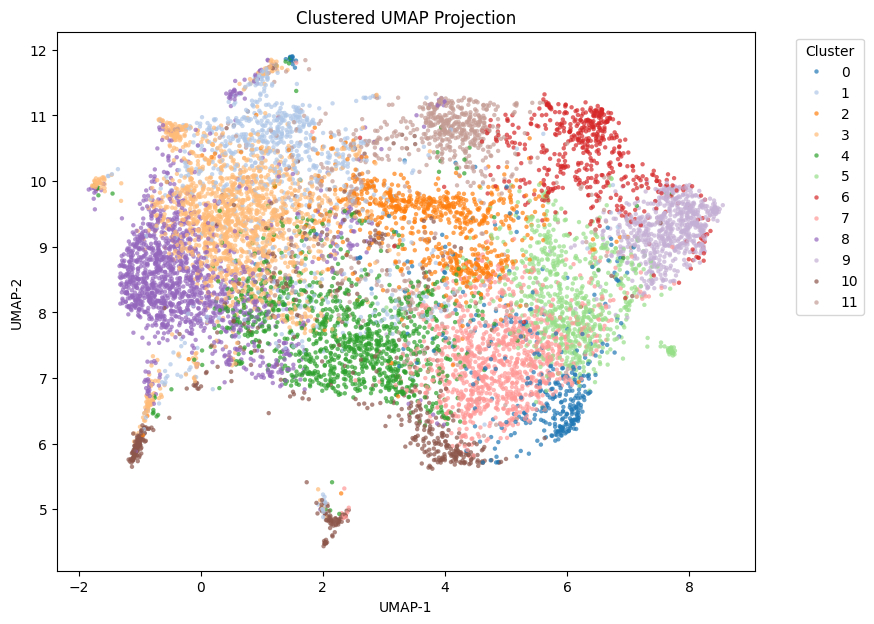

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,7))
sns.scatterplot(
    x=umap_X[:,0], y=umap_X[:,1],
    hue=labels, palette='tab20',
    s=10, alpha=0.7, linewidth=0
)

plt.title("Clustered UMAP Projection")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

cluster_centroids = {}

for c in sorted(df['cluster'].unique()):
    centroid = X[df['cluster'] == c].mean(axis=0)
    cluster_centroids[c] = centroid

def top_docs_in_cluster(c, top_n=5):
    """Return titles of documents closest to the cluster centroid."""
    inds = np.where(df['cluster'] == c)[0]
    sims = cosine_similarity(
        X[inds], cluster_centroids[c].reshape(1, -1)
    ).ravel()
    top_idx = inds[np.argsort(-sims)[:top_n]]
    return df.loc[top_idx, ['title', 'abstract']]

# Example: top docs for cluster 0
top_docs_in_cluster(0, top_n=5)


,title,abstract
2531,A common NFKB1 variant detected through antibo...,Infectious agents contribute significantly to ...
3609,X-linked genetic risk factors that promote aut...,BACKGROUND: Multiple sclerosis (MS) is a chron...
1562,A genome-wide meta-analysis identifies 50 gene...,Carpal tunnel syndrome (CTS) is the most commo...
6719,TP53-mediated clonal hematopoiesis confers inc...,Somatic mutations in blood indicative of clona...
2293,Genetic Exploration of Targeting the Transient...,The transient receptor potential cation channe...


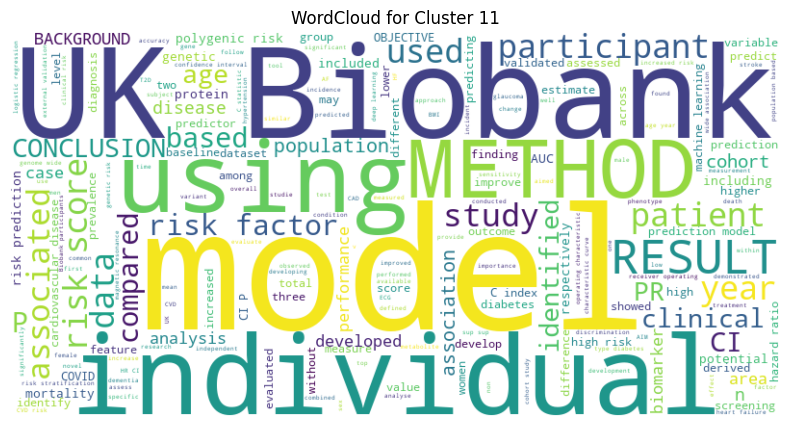

In [36]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt

def cluster_wordcloud(c):
    texts = df[df['cluster'] == c]['abstract'].dropna().astype(str)
    text = " ".join(texts)
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for Cluster {c}")
    plt.show()

cluster_wordcloud(11)


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,        # keep vocabulary manageable
    stop_words='english',
    ngram_range=(1,2),
)
tfidf = vectorizer.fit_transform(df['abstract'].astype(str))
feature_names = np.array(vectorizer.get_feature_names_out())


In [39]:
import numpy as np

k = df['cluster'].nunique()
cluster_keyword_weights = np.zeros((k, tfidf.shape[1]))

for c in range(k):
    idx = np.where(labels == c)[0]
    if len(idx) > 0:
        cluster_keyword_weights[c] = tfidf[idx].mean(axis=0)


In [40]:
def top_keywords_preferring_bigrams(topic_idx, top_n=10):
    row = c_tfidf[topic_idx].toarray().ravel()
    # mask to keep only bigrams (contain a space)
    is_bigram = np.char.find(feature_names, " ") >= 0
    if is_bigram.sum() >= top_n:
        row_masked = np.where(is_bigram, row, 0.0)
    else:
        row_masked = row  # fall back to all terms

    top_ids = np.argsort(row_masked)[::-1][:top_n]
    return feature_names[top_ids], row[top_ids]

# Display top keywords for cluster 0
top_keywords(0, top_n=15)


[('mice', np.float64(0.038076427746195546)),
 ('variants', np.float64(0.036062707281188586)),
 ('cells', np.float64(0.033076048117559376)),
 ('expression', np.float64(0.03156919212195557)),
 ('human', np.float64(0.029133167794621915)),
 ('disease', np.float64(0.028673969608125273)),
 ('genetic', np.float64(0.027982310497647496)),
 ('cell', np.float64(0.02732254195154223)),
 ('associated', np.float64(0.026975271334666907)),
 ('gene', np.float64(0.026168819608507886)),
 ('risk', np.float64(0.025997232477783235)),
 ('genes', np.float64(0.02537896764809053)),
 ('mutations', np.float64(0.024102283512805123)),
 ('loss', np.float64(0.021679360494902274)),
 ('protein', np.float64(0.02159247775615473))]

In [ ]:
top_keywords_preferring_bigrams(topic_idx, top_n=10)

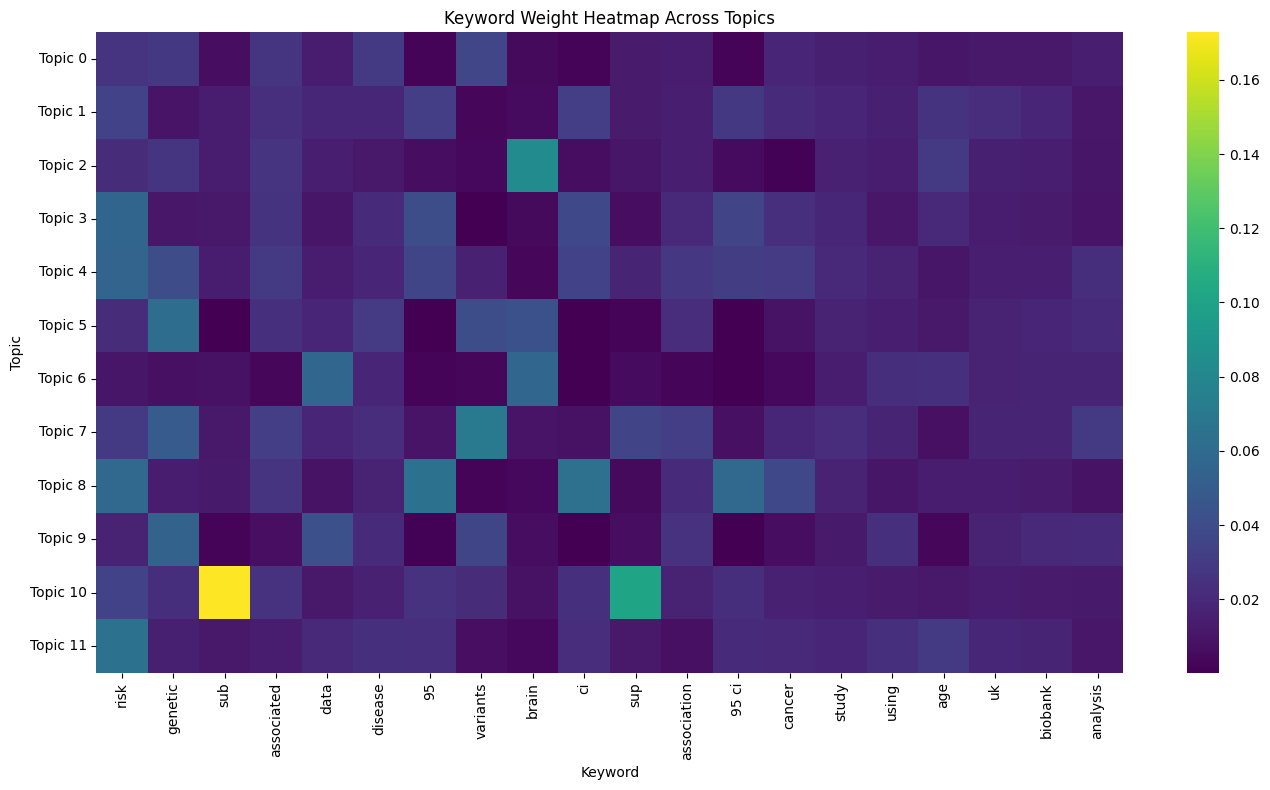

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

top_k = 20  # keywords displayed on heatmap

# find globally highest-weight terms
global_top_ids = np.argsort(cluster_keyword_weights.mean(axis=0))[::-1][:top_k]

heat_data = cluster_keyword_weights[:, global_top_ids]

plt.figure(figsize=(14,8))
sns.heatmap(
    heat_data,
    xticklabels=feature_names[global_top_ids],
    yticklabels=[f"Topic {i}" for i in range(k)],
    cmap="viridis"
)
plt.title("Keyword Weight Heatmap Across Topics")
plt.xlabel("Keyword")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Candidate topic counts
candidate_K = [12, 16, 20]

sil_scores = []
db_scores = []
ch_scores = []

print("Evaluating k in {12, 16, 20}...\n")

for k in candidate_K:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_k = km.fit_predict(X)

    sil = silhouette_score(X, labels_k)
    db  = davies_bouldin_score(X, labels_k)
    ch  = calinski_harabasz_score(X, labels_k)

    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)

    print(f"k={k}: silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.4f}")

# Normalised ranking score (higher = better)
sil_norm = (sil_scores - np.min(sil_scores)) / (np.max(sil_scores) - np.min(sil_scores))
db_norm  = (np.max(db_scores) - db_scores) / (np.max(db_scores) - np.min(db_scores))  # lower DB is better
ch_norm  = (ch_scores - np.min(ch_scores)) / (np.max(ch_scores) - np.min(ch_scores))

combined = sil_norm + db_norm + ch_norm

best_k = candidate_K[np.argmax(combined)]

print("\nSelected number of topics:", best_k)

# Fit final clustering using best_k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)
df["cluster"] = labels


Evaluating k in {12, 16, 20}...

k=12: silhouette=0.0337, DB=3.5762, CH=304.6548
k=16: silhouette=0.0312, DB=3.6257, CH=245.0964
k=20: silhouette=0.0227, DB=3.7228, CH=206.3582

Selected number of topics: 12


In [45]:
# TF-IDF over corpus
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf = vectorizer.fit_transform(df["abstract"].astype(str))
feature_names = np.array(vectorizer.get_feature_names_out())

# Compute per-topic keyword weights
k = best_k
cluster_keyword_weights = np.zeros((k, tfidf.shape[1]))

for c in range(k):
    idx = np.where(df["cluster"] == c)[0]
    if len(idx) > 0:
        cluster_keyword_weights[c] = tfidf[idx].mean(axis=0)

# Function to get top keywords
def top_keywords(cluster_idx, top_n=10):
    weights = cluster_keyword_weights[cluster_idx]
    top_ids = np.argsort(weights)[::-1][:top_n]
    return feature_names[top_ids], weights[top_ids]

# Plotting in a grid of 4 columns
cols = 4
rows = int(np.ceil(k / cols))

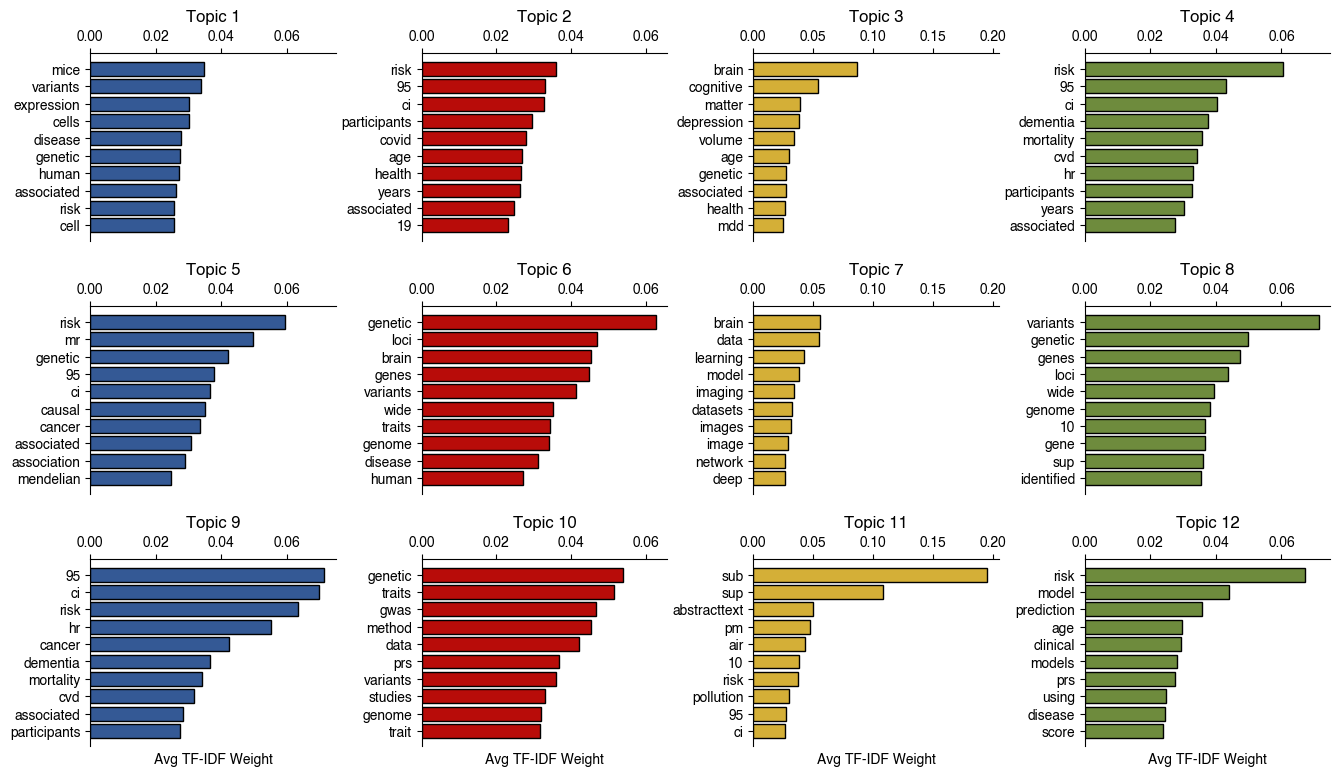

In [72]:
# === Custom Regal Color Palette ===
regal_colors = [
    "#345995",  # UKBB
    "#B80C09",  # FHS
    "#D4AF37",  # HRS
    "#6E8B3D",  # UKHLS (Olive Green)
]

cols = 4
rows = int(np.ceil(k / cols))

# create grid, but DO NOT share x globally
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))
axes = axes.flatten()

# enforce sharex only within each column
for col in range(cols):
    col_axes = axes[col::cols]
    for ax in col_axes[1:]:
        ax.sharex(col_axes[0])

# plot each topic
for c in range(k):
    words, weights = top_keywords(c, top_n=10)
    
    ax = axes[c]
    color = regal_colors[c % len(regal_colors)]
    
    ax.barh(words[::-1], weights[::-1], color=color, edgecolor='k')
    ax.set_title(f"Topic {c+1}", fontsize=12)

# hide unused panels + control x-axis label visibility
for idx, ax in enumerate(axes):
    row_idx = idx // cols
    if idx >= k:
        ax.axis("off")
    else:
        if row_idx == rows - 1:
            ax.set_xlabel("Avg TF-IDF Weight")
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

# Increase vertical space between rows
plt.subplots_adjust(hspace=0.35, wspace=0.35)
plt.rcParams['font.family'] = 'Helvetica'

import seaborn as sns
sns.despine(top=False, bottom=True, left=False, right=True)
plt.savefig("../output/figures/scibert_topic_model.pdf", bbox_inches='tight')
plt.savefig("../output/figures/scibert_topic_model.svg", bbox_inches='tight')
plt.savefig("../output/figures/scibert_topic_model.png", bbox_inches='tight', dpi=1200)